# NLA compressor model selection

This notebook is the sole validation-only selection authority for matched-rank PCA, PCA-AE, Conv1D, and Conv2D compressors. It authenticates the current run grid, shows incomplete coverage before ranking, calculates compact and accuracy-oriented decisions globally and within each neural family, and writes the exact live hand-off consumed by the two method notebooks.

The execution order is **ModelSelection -> AE -> PCA-AE**. The live decision is provisional while configurations are incomplete and seed replication is absent. No test artifact is opened or authorized here.


In [1]:
import csv
import hashlib
import json
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

In [2]:
import matplotlib
import numpy as np
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

In [3]:
def find_project_root(
    start: Path,
) -> Path:
    """
    Find the repository root from a notebook working directory.
    
    Arguments:
        start (pathlib.Path):
            Initial directory used for the upward search.
    
    Returns:
        root (pathlib.Path):
            IAFlowCloud repository root.
    """
    for candidate in (start, *start.parents):
        if (candidate / "Code" / "iaflow").is_dir() and (
            candidate / "Config" / "NLA"
        ).is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the IAFlowCloud repository root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
CODE_ROOT = PROJECT_ROOT / "Code"
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

warnings.filterwarnings("ignore", message="IProgress not found.*")

from iaflow.comparison import (  # noqa: E402
    audit_compressor_runs,
    compressor_selection_input_sha256,
    expected_compressor_cells,
    notebook_source_sha256,
)
from iaflow.core.artifacts import save_json  # noqa: E402
from iaflow.validation_visuals import (  # noqa: E402
    DEPTH_MARKERS,
    FAMILY_COLORS,
    FIGURE_SIZES,
    METRIC_PRESENTATION,
    SELECTION_MARKERS,
    apply_validation_style,
    plot_validation_metric_panel,
    positive_log_limits,
    save_validation_figure,
    selection_legend_handles,
)


LATENT_DIMENSIONS = (2, 4, 6, 8, 10)
DEPTHS = ("Depth03", "Depth04", "Depth05")
TARGET_VARIANCE_RECOVERED = 0.999
PRIMARY_METRIC = "log10_rmse"
REQUIRED_SEEDS = (42,)

SELECTION_POLICY = {
    "diagnostic_role": "family_minimum_adequate",
    "latent_dimensions": list(LATENT_DIMENSIONS),
    "minimum_variance_recovered": TARGET_VARIANCE_RECOVERED,
    "require_matched_pca_outperformance": True,
    "headline_metrics": [
        "log10_rmse",
        "mean_relative_error",
        "surface_relative_rmse_p95",
        "surface_relative_maximum_p99",
    ],
    "primary_metric": PRIMARY_METRIC,
    "replicates": {
        "required_seeds": list(REQUIRED_SEEDS),
        "aggregate": "median",
        "duplicate_seed_policy": "error",
        "outperformance_gate": "all_required_seeds",
        "diagnostic_replicate": (
            "closest_to_median_log10_rmse_then_seed_then_run_directory"
        ),
    },
    "minimum_adequate_order": [
        "latent_dim",
        "codec_state_scalars",
        "log10_mse",
        "cell_id",
    ],
    "best_accuracy_order": [
        "log10_rmse",
        "mean_relative_error",
        "surface_relative_rmse_p95",
        "surface_relative_maximum_p99",
        "latent_dim",
        "codec_state_scalars",
        "cell_id",
    ],
}

PCA_METRICS_PATH = PROJECT_ROOT / "Data" / "NLA" / "PCA" / "PCAValidationMetrics.json"
PCA_METADATA_PATH = PROJECT_ROOT / "Data" / "NLA" / "PCA" / "PCATransformMetadata.json"
SELECTION_NOTEBOOK_PATH = PROJECT_ROOT / "Notebooks" / "NLA" / "ModelSelection.ipynb"
FIGURE_DIRECTORY = PROJECT_ROOT / "Figure" / "NLA" / "ModelSelection"
RESULT_DIRECTORY = PROJECT_ROOT / "Data" / "NLA" / "Comparison"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
RESULT_DIRECTORY.mkdir(parents=True, exist_ok=True)

apply_validation_style()

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Diagnostic policy: {SELECTION_POLICY['diagnostic_role']}")


Project root: /Users/s2227120/IAFlowCloud
Python: 3.12.13
NumPy: 2.0.2
Matplotlib: 3.10.9
Diagnostic policy: family_minimum_adequate


## Reproducibility helpers

Content hashes identify the exact policy, configuration templates, PCA reference, validation artifacts, tables, and selected diagnostic runs. Freshness is established directly from those contents rather than from a timestamp. Figures are also replaced atomically so interrupted execution cannot leave partial PDFs.


In [4]:
def read_json(
    path: Path,
) -> dict:
    """
    Load one JSON mapping.
    
    Arguments:
        path (pathlib.Path):
            Existing JSON artifact.
    
    Returns:
        values (dict):
            Parsed JSON mapping.
    """
    with path.open("r", encoding="utf-8") as stream:
        values = json.load(stream)
    if not isinstance(values, dict):
        raise ValueError(f"Expected a JSON mapping: {path}")
    return values


def file_sha256(
    path: Path,
) -> str:
    """
    Calculate the SHA-256 digest of one file.
    
    Arguments:
        path (pathlib.Path):
            Existing file path.
    
    Returns:
        digest (str):
            Lowercase hexadecimal SHA-256 digest.
    """
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def display_markdown_table(
    headers: tuple[str, ...],
    rows: list[tuple[object, ...]],
) -> None:
    """
    Display a compact Markdown table without a dataframe dependency.
    
    Arguments:
        headers (tuple[str, ...]):
            Ordered column labels.
        rows (list[tuple[object, ...]]):
            Ordered table values.
    """
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    lines.extend(
        "| " + " | ".join(str(value) for value in row) + " |" for row in rows
    )
    display(Markdown("\n".join(lines)))


def save_figure(
    figure: plt.Figure,
    filename: str,
) -> Path:
    """
    Save and display one model-selection conclusion figure.
    
    Arguments:
        figure (matplotlib.figure.Figure):
            Completed Matplotlib figure.
        filename (str):
            PDF filename below the model-selection figure directory.
    
    Returns:
        path (pathlib.Path):
            Saved non-empty PDF path.
    """
    path = save_validation_figure(
        figure,
        FIGURE_DIRECTORY / filename,
        creator="ModelSelection.ipynb",
    )
    display(figure)
    plt.close(figure)
    return path


def git_state() -> dict[str, object]:
    """
    Record the repository commit and dirty state.
    
    Returns:
        state (dict[str, object]):
            Commit hash and Boolean dirty flag.
    """
    commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=PROJECT_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
    status = subprocess.run(
        ["git", "status", "--porcelain"],
        cwd=PROJECT_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout
    return {"commit": commit, "dirty": bool(status.strip())}


## Authenticated PCA reference and live run audit

The expected neural grid contains 45 cells: three PCA-AE depths, three Conv1D depths, and three Conv2D depths, each evaluated at five latent dimensions. Every discovered run remains visible in the audit. Only complete, content-validated runs matching the current templates can enter a table, selection, or figure.


In [5]:
AUDIT_CREATED_AT = datetime.now(timezone.utc).isoformat()
pca_reference = read_json(PCA_METRICS_PATH)
pca_metadata = read_json(PCA_METADATA_PATH)
pca_number_of_features = int(pca_metadata["number_of_features"])
pca_transform_rank = int(pca_metadata["rank"])
selection_notebook_source_sha256 = notebook_source_sha256(
    SELECTION_NOTEBOOK_PATH
)

assert pca_reference["split"] == "validation"
assert pca_reference["transform"] == "log10"
assert pca_reference["centering"] == "training feature mean"
assert pca_reference["normalization"] == "global_rms"
assert file_sha256(PCA_METRICS_PATH) == pca_metadata["validation_metrics_sha256"]
assert pca_number_of_features == int(np.prod(pca_metadata["input_shape"]))
assert pca_transform_rank == int(pca_reference["adopted_precision_rank"])

pca_rows = []
for latent_dim in LATENT_DIMENSIONS:
    metrics = pca_reference["ranks"][str(latent_dim)]
    assert int(metrics["number_of_surfaces"]) == 10000
    pca_rows.append(
        {
            "cell_id": f"PCA:Rank{latent_dim:02d}",
            "model_family": "PCA",
            "architecture": "PCA",
            "depth": "PCA",
            "latent_dim": latent_dim,
            "learned_parameters": 0,
            "codec_state_scalars": (
                pca_number_of_features * latent_dim
                + pca_number_of_features
            ),
            **{name: float(value) for name, value in metrics.items()},
        }
    )

selection_input_sha256 = compressor_selection_input_sha256(
    PROJECT_ROOT,
    policy=SELECTION_POLICY,
    pca_metrics_path=PCA_METRICS_PATH,
    pca_metadata_path=PCA_METADATA_PATH,
    latent_dimensions=LATENT_DIMENSIONS,
)
expected_cells = expected_compressor_cells(
    PROJECT_ROOT,
    latent_dimensions=LATENT_DIMENSIONS,
)
run_audits = audit_compressor_runs(
    PROJECT_ROOT,
    latent_dimensions=LATENT_DIMENSIONS,
)
eligible_audits = [
    audit for audit in run_audits if audit["eligible_for_comparison"]
]
eligible_results = [audit["result"] for audit in eligible_audits]

assert len(expected_cells) == 45
assert all(result["validation_samples"] == 10000 for result in eligible_results)
assert all(
    result["test_split_used_during_training"] is False
    for result in eligible_results
)
assert all(
    result["pca_comparison"]["pca_metrics"]
    == pca_reference["ranks"][str(result["latent_dim"])]
    for result in eligible_results
)

print(f"Expected neural cells: {len(expected_cells)}")
print(f"Eligible neural runs: {len(eligible_results)}")
print(f"Audit records including missing/legacy: {len(run_audits)}")
print(f"Selection input: {selection_input_sha256[:12]}...")


Expected neural cells: 45
Eligible neural runs: 29
Audit records including missing/legacy: 51
Selection input: bef72f8c60ef...


In [6]:
audits_by_cell = defaultdict(list)
for audit in run_audits:
    audits_by_cell[audit["cell_id"]].append(audit)


def cell_status(
    audits: list[dict],
) -> str:
    """
    Summarize candidate audits for one expected grid cell.
    
    Arguments:
        audits (list[dict]):
            Candidate and missing audit records for one cell.
    
    Returns:
        status (str):
            Highest-priority current status with legacy context.
    """
    statuses = {audit["status"] for audit in audits}
    legacy_suffix = " + legacy" if "legacy" in statuses else ""
    if "eligible" in statuses:
        return "eligible" + legacy_suffix
    for status in ("validation pending", "training", "invalid"):
        if status in statuses:
            return status + legacy_suffix
    if "legacy" in statuses:
        return "legacy only"
    return "missing"


coverage_rows = []
for family, architecture in (
    ("PCA_AE", "PCA_AE"),
    ("Direct_AE", "Conv1D"),
    ("Direct_AE", "Conv2D"),
):
    for depth in DEPTHS:
        statuses = []
        for latent_dim in LATENT_DIMENSIONS:
            cell_id = f"{family}:{architecture}:{depth}:L{latent_dim:02d}"
            statuses.append(cell_status(audits_by_cell[cell_id]))
        coverage_rows.append((architecture, depth, *statuses))

display_markdown_table(
    ("Architecture", "Depth", "L=2", "L=4", "L=6", "L=8", "L=10"),
    coverage_rows,
)

status_counts = Counter(audit["status"] for audit in run_audits)
coverage_by_architecture = {}
for architecture in ("PCA_AE", "Conv1D", "Conv2D"):
    expected_ids = {
        cell["cell_id"]
        for cell in expected_cells
        if cell["architecture"] == architecture
    }
    architecture_audits = [
        audit for audit in run_audits if audit["architecture"] == architecture
    ]
    coverage_by_architecture[architecture] = {
        "expected_cells": len(expected_ids),
        "eligible_cells": len(
            {
                audit["cell_id"]
                for audit in architecture_audits
                if audit["eligible_for_comparison"]
            }
        ),
        "training_cells": len(
            {
                audit["cell_id"]
                for audit in architecture_audits
                if audit["status"] == "training"
            }
        ),
        "missing_records": sum(
            audit["status"] == "missing" for audit in architecture_audits
        ),
        "legacy_run_records": sum(
            audit["status"] == "legacy" for audit in architecture_audits
        ),
    }

excluded_rows = []
for audit in run_audits:
    if audit["run_directory"] is None or audit["eligible_for_comparison"]:
        continue
    excluded_rows.append(
        (
            audit["architecture"],
            audit["depth"],
            audit["latent_dim"],
            audit["status"],
            audit["run_directory"],
            "; ".join(audit["exclusion_reasons"] or audit["warnings"]),
        )
    )
display(Markdown("### Excluded or incomplete run directories"))
display_markdown_table(
    ("Architecture", "Depth", "L", "Status", "Run", "Reason"),
    excluded_rows,
)


| Architecture | Depth | L=2 | L=4 | L=6 | L=8 | L=10 |
| --- | --- | --- | --- | --- | --- | --- |
| PCA_AE | Depth03 | eligible | eligible | eligible | eligible | eligible |
| PCA_AE | Depth04 | eligible | eligible | eligible | eligible | eligible |
| PCA_AE | Depth05 | eligible | eligible | eligible | eligible | eligible |
| Conv1D | Depth03 | eligible | eligible | eligible | eligible | eligible |
| Conv1D | Depth04 | eligible + legacy | eligible + legacy | eligible + legacy | eligible + legacy | eligible + legacy |
| Conv1D | Depth05 | eligible | eligible | eligible | eligible | training |
| Conv2D | Depth03 | training + legacy | legacy only | legacy only | missing | missing |
| Conv2D | Depth04 | missing | missing | missing | missing | missing |
| Conv2D | Depth05 | missing | missing | missing | missing | missing |

### Excluded or incomplete run directories

| Architecture | Depth | L | Status | Run | Reason |
| --- | --- | --- | --- | --- | --- |
| Conv1D | Depth04 | 2 | legacy | Runs/NLA/AE/Conv1D/Depth04/Latent02/20260818-155851 | resolved settings differ from the current template |
| Conv1D | Depth04 | 4 | legacy | Runs/NLA/AE/Conv1D/Depth04/Latent04/20260818-155851 | resolved settings differ from the current template |
| Conv1D | Depth04 | 6 | legacy | Runs/NLA/AE/Conv1D/Depth04/Latent06/20260818-155851 | resolved settings differ from the current template |
| Conv1D | Depth04 | 8 | legacy | Runs/NLA/AE/Conv1D/Depth04/Latent08/20260818-155851 | resolved settings differ from the current template |
| Conv1D | Depth04 | 10 | legacy | Runs/NLA/AE/Conv1D/Depth04/Latent10/20260818-155851 | resolved settings differ from the current template |
| Conv1D | Depth05 | 10 | training | Runs/NLA/AE/Conv1D/Depth05/Latent10/20260830-115056 | training artifacts pending: Summary.json |
| Conv2D | Depth03 | 2 | legacy | Runs/NLA/AE/Conv2D/Depth03/Latent02/20260819-214942 | resolved settings differ from the current template |
| Conv2D | Depth03 | 2 | training | Runs/NLA/AE/Conv2D/Depth03/Latent02/20260831-165102 | training artifacts pending: Summary.json |
| Conv2D | Depth03 | 4 | legacy | Runs/NLA/AE/Conv2D/Depth03/Latent04/20260819-214942 | resolved settings differ from the current template |
| Conv2D | Depth03 | 6 | legacy | Runs/NLA/AE/Conv2D/Depth03/Latent06/20260819-214942 | resolved settings differ from the current template |

## Aggregated validation results, complexity, and decisions

Results are aggregated once per architecture, depth, latent dimension, and network template. Configuration selection uses medians across seeds. A diagnostic replicate is chosen deterministically as the run closest to the configuration's median log-RMSE; the best seed is never selected merely because it is best.


In [7]:
METRIC_NAMES = (
    "normalized_mse",
    "variance_recovered",
    "log10_mse",
    "log10_rmse",
    "log10_mae",
    "mean_relative_error",
    "maximum_relative_error",
    "surface_relative_rmse_p95",
    "surface_relative_rmse_p99",
    "surface_relative_maximum_p95",
    "surface_relative_maximum_p99",
)

grouped_results = defaultdict(list)
for result in eligible_results:
    key = (
        result["model_family"],
        result["architecture"],
        result["depth"],
        result["latent_dim"],
        tuple(result["dense_hidden"]),
    )
    grouped_results[key].append(result)

aggregated_results = []
for key, records in sorted(grouped_results.items()):
    family, architecture, depth, latent_dim, dense_hidden = key
    seed_values = sorted({record["training_seed"] for record in records})
    if len(seed_values) != len(records):
        raise RuntimeError(
            f"Duplicate eligible seed in {family}:{architecture}:{depth}:L{latent_dim:02d}."
        )
    if seed_values != list(REQUIRED_SEEDS):
        raise RuntimeError(
            f"Required seeds {list(REQUIRED_SEEDS)} are not complete for "
            f"{family}:{architecture}:{depth}:L{latent_dim:02d}: "
            f"found {seed_values}."
        )
    learned_parameters = int(
        np.median([record["number_of_parameters"] for record in records])
    )
    fixed_buffers = (
        pca_transform_rank * pca_number_of_features
        + 2 * pca_number_of_features
        + 2 * pca_transform_rank
        + 1
        if family == "PCA_AE"
        else pca_number_of_features + 1
    )
    median_log10_rmse = float(
        np.median([record["log10_rmse"] for record in records])
    )
    representative = min(
        records,
        key=lambda record: (
            abs(float(record["log10_rmse"]) - median_log10_rmse),
            int(record["training_seed"]),
            record["run_directory"],
        ),
    )
    row = {
        "cell_id": f"{family}:{architecture}:{depth}:L{latent_dim:02d}",
        "model_family": family,
        "architecture": architecture,
        "depth": depth,
        "latent_dim": latent_dim,
        "dense_hidden": list(dense_hidden),
        "n_runs": len(records),
        "n_seeds": len(seed_values),
        "seeds": seed_values,
        "run_directories": sorted(record["run_directory"] for record in records),
        "representative_run_directory": representative["run_directory"],
        "representative_seed": int(representative["training_seed"]),
        "representative_checkpoint_epoch": int(representative["best_epoch"]),
        "learned_parameters": learned_parameters,
        "codec_state_scalars": learned_parameters + fixed_buffers,
        "diagnostics_ready": all(record["diagnostics_ready"] for record in records),
        "latents_available": all(record["latents_available"] for record in records),
        "autoencoder_outperforms_pca": all(
            record["autoencoder_outperforms_pca"] for record in records
        ),
    }
    for metric_name in METRIC_NAMES:
        values = np.asarray(
            [record[metric_name] for record in records],
            dtype=float,
        )
        row[metric_name] = float(np.median(values))
        row[f"{metric_name}_minimum"] = float(np.min(values))
        row[f"{metric_name}_maximum"] = float(np.max(values))
    reductions = {}
    for metric_name in records[0]["fractional_error_reduction"]:
        values = [
            record["fractional_error_reduction"][metric_name]
            for record in records
        ]
        reductions[metric_name] = float(np.median(values))
    row["fractional_error_reduction"] = reductions
    row["target_met"] = (
        row["variance_recovered"] >= TARGET_VARIANCE_RECOVERED
    )
    aggregated_results.append(row)


def minimum_adequate_result(
    rows: list[dict],
) -> dict:
    """
    Select the smallest adequate compressor from one result scope.
    
    Arguments:
        rows (list[dict]):
            Aggregated configuration records in the requested scope.
    
    Returns:
        result (dict):
            Deterministically selected minimum-adequate record.
    """
    qualified = [
        row
        for row in rows
        if row["target_met"]
        and row["autoencoder_outperforms_pca"]
        and row["diagnostics_ready"]
    ]
    if not qualified:
        raise RuntimeError("No configuration satisfies the adequacy policy.")
    return min(
        qualified,
        key=lambda row: (
            row["latent_dim"],
            row["codec_state_scalars"],
            row["log10_mse"],
            row["cell_id"],
        ),
    )


def best_accuracy_result(
    rows: list[dict],
) -> dict:
    """
    Select the best observed validation accuracy in one result scope.
    
    Arguments:
        rows (list[dict]):
            Aggregated configuration records in the requested scope.
    
    Returns:
        result (dict):
            Deterministically selected best-accuracy record.
    """
    return min(
        rows,
        key=lambda row: (
            row["log10_rmse"],
            row["mean_relative_error"],
            row["surface_relative_rmse_p95"],
            row["surface_relative_maximum_p99"],
            row["latent_dim"],
            row["codec_state_scalars"],
            row["cell_id"],
        ),
    )


family_rows = {
    "AE": [
        row for row in aggregated_results if row["model_family"] == "Direct_AE"
    ],
    "PCA_AE": [
        row for row in aggregated_results if row["model_family"] == "PCA_AE"
    ],
}
family_decisions = {
    family: {
        "minimum_adequate": minimum_adequate_result(rows),
        "best_observed_accuracy": best_accuracy_result(rows),
    }
    for family, rows in family_rows.items()
}
global_minimum_adequate = minimum_adequate_result(aggregated_results)
global_best_accuracy = best_accuracy_result(aggregated_results)
minimum_adequate = global_minimum_adequate
best_observed = global_best_accuracy
qualified_results = [
    row
    for row in aggregated_results
    if row["target_met"] and row["autoencoder_outperforms_pca"]
]
compact_cell_ids = {
    decision["minimum_adequate"]["cell_id"]
    for decision in family_decisions.values()
}
accuracy_cell_ids = {
    decision["best_observed_accuracy"]["cell_id"]
    for decision in family_decisions.values()
}

result_rows = []
for row in aggregated_results:
    result_rows.append(
        (
            row["architecture"],
            row["depth"].replace("Depth", "D"),
            row["latent_dim"],
            f"{row['learned_parameters']:,}",
            f"{row['log10_rmse']:.6g}",
            f"{100.0 * row['mean_relative_error']:.3f}",
            f"{100.0 * row['surface_relative_rmse_p95']:.3f}",
            f"{100.0 * row['surface_relative_maximum_p99']:.3f}",
            f"{100.0 * row['variance_recovered']:.5f}",
            "yes" if row["autoencoder_outperforms_pca"] else "no",
        )
    )
display_markdown_table(
    (
        "Architecture",
        "Depth",
        "L",
        "Learned parameters",
        "log-RMSE [dex]",
        "Mean [%]",
        "p95 RMS [%]",
        "p99 max [%]",
        "Variance [%]",
        "Passes matched PCA",
    ),
    result_rows,
)

selection_rows = []
for family, decision in family_decisions.items():
    for role in ("minimum_adequate", "best_observed_accuracy"):
        row = decision[role]
        selection_rows.append(
            (
                family,
                role.replace("_", " "),
                row["architecture"],
                row["depth"],
                row["latent_dim"],
                f"{row['log10_rmse']:.6g}",
                f"{row['surface_relative_maximum_p99'] * 100.0:.3f}",
                f"{row['codec_state_scalars']:,}",
            )
        )
for role, row in (
    ("minimum adequate", global_minimum_adequate),
    ("best observed accuracy", global_best_accuracy),
):
    selection_rows.append(
        (
            "Global",
            role,
            row["architecture"],
            row["depth"],
            row["latent_dim"],
            f"{row['log10_rmse']:.6g}",
            f"{row['surface_relative_maximum_p99'] * 100.0:.3f}",
            f"{row['codec_state_scalars']:,}",
        )
    )
display(Markdown("### Validation-only decisions"))
display_markdown_table(
    (
        "Scope",
        "Role",
        "Architecture",
        "Depth",
        "L",
        "log-RMSE",
        "p99 max [%]",
        "Codec state",
    ),
    selection_rows,
)


| Architecture | Depth | L | Learned parameters | log-RMSE [dex] | Mean [%] | p95 RMS [%] | p99 max [%] | Variance [%] | Passes matched PCA |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Conv1D | D03 | 2 | 2,041,857 | 0.0351102 | 5.952 | 12.783 | 62.236 | 98.36205 | yes |
| Conv1D | D03 | 4 | 2,041,923 | 0.0156793 | 2.507 | 6.071 | 38.236 | 99.67334 | yes |
| Conv1D | D03 | 6 | 2,041,989 | 0.00794565 | 1.246 | 3.214 | 17.172 | 99.91611 | yes |
| Conv1D | D03 | 8 | 2,042,055 | 0.00387165 | 0.576 | 1.608 | 11.140 | 99.98008 | yes |
| Conv1D | D03 | 10 | 2,042,121 | 0.00156733 | 0.244 | 0.706 | 3.789 | 99.99674 | yes |
| Conv1D | D04 | 2 | 5,058,561 | 0.0360337 | 6.047 | 13.120 | 62.300 | 98.27475 | yes |
| Conv1D | D04 | 4 | 5,058,627 | 0.0157398 | 2.520 | 6.057 | 38.182 | 99.67082 | yes |
| Conv1D | D04 | 6 | 5,058,693 | 0.00763778 | 1.191 | 3.077 | 17.072 | 99.92249 | yes |
| Conv1D | D04 | 8 | 5,058,759 | 0.00359056 | 0.535 | 1.517 | 9.062 | 99.98287 | yes |
| Conv1D | D04 | 10 | 5,058,825 | 0.00252179 | 0.385 | 1.063 | 6.804 | 99.99155 | yes |
| Conv1D | D05 | 2 | 9,255,169 | 0.0368026 | 6.198 | 13.369 | 66.968 | 98.20033 | yes |
| Conv1D | D05 | 4 | 9,255,235 | 0.0158016 | 2.529 | 6.037 | 38.310 | 99.66823 | yes |
| Conv1D | D05 | 6 | 9,255,301 | 0.00739526 | 1.149 | 2.992 | 16.525 | 99.92733 | yes |
| Conv1D | D05 | 8 | 9,255,367 | 0.00356378 | 0.529 | 1.497 | 9.407 | 99.98312 | yes |
| PCA_AE | D03 | 2 | 50,944 | 0.0410391 | 6.773 | 15.693 | 76.626 | 97.76215 | yes |
| PCA_AE | D03 | 4 | 51,010 | 0.0165713 | 2.634 | 6.401 | 37.001 | 99.63512 | yes |
| PCA_AE | D03 | 6 | 51,076 | 0.00778619 | 1.215 | 3.144 | 16.788 | 99.91945 | yes |
| PCA_AE | D03 | 8 | 51,142 | 0.00391825 | 0.587 | 1.610 | 11.116 | 99.97960 | yes |
| PCA_AE | D03 | 10 | 51,208 | 0.00169819 | 0.267 | 0.696 | 4.607 | 99.99617 | yes |
| PCA_AE | D04 | 2 | 329,472 | 0.0379684 | 6.284 | 14.300 | 69.835 | 98.08451 | yes |
| PCA_AE | D04 | 4 | 329,538 | 0.0162563 | 2.591 | 6.314 | 35.982 | 99.64886 | yes |
| PCA_AE | D04 | 6 | 329,604 | 0.00748909 | 1.162 | 3.035 | 16.134 | 99.92548 | yes |
| PCA_AE | D04 | 8 | 329,670 | 0.00385143 | 0.571 | 1.650 | 10.483 | 99.98029 | yes |
| PCA_AE | D04 | 10 | 329,736 | 0.00193952 | 0.295 | 0.831 | 4.955 | 99.99500 | yes |
| PCA_AE | D05 | 2 | 1,132,800 | 0.0390842 | 6.415 | 14.269 | 70.495 | 97.97027 | yes |
| PCA_AE | D05 | 4 | 1,132,866 | 0.0155037 | 2.452 | 6.028 | 35.794 | 99.68062 | yes |
| PCA_AE | D05 | 6 | 1,132,932 | 0.00762795 | 1.178 | 3.129 | 16.304 | 99.92269 | yes |
| PCA_AE | D05 | 8 | 1,132,998 | 0.0039917 | 0.586 | 1.695 | 9.596 | 99.97883 | yes |
| PCA_AE | D05 | 10 | 1,133,064 | 0.00186811 | 0.263 | 0.819 | 4.701 | 99.99536 | yes |

### Validation-only decisions

| Scope | Role | Architecture | Depth | L | log-RMSE | p99 max [%] | Codec state |
| --- | --- | --- | --- | --- | --- | --- | --- |
| AE | minimum adequate | Conv1D | Depth03 | 6 | 0.00794565 | 17.172 | 2,045,121 |
| AE | best observed accuracy | Conv1D | Depth03 | 10 | 0.00156733 | 3.789 | 2,045,253 |
| PCA_AE | minimum adequate | PCA_AE | Depth03 | 6 | 0.00778619 | 16.788 | 151,329 |
| PCA_AE | best observed accuracy | PCA_AE | Depth03 | 10 | 0.00169819 | 4.607 | 151,461 |
| Global | minimum adequate | PCA_AE | Depth03 | 6 | 0.00778619 | 16.788 | 151,329 |
| Global | best observed accuracy | Conv1D | Depth03 | 10 | 0.00156733 | 3.789 | 2,045,253 |

## Global and typical validation accuracy

The left panel measures global reconstruction accuracy in log space. The right panel measures the mean physical-amplitude error. Filled neural markers satisfy the 99.9% variance-recovery gate; open neural markers do not. Stars identify the minimum-adequate configuration within each family, and crosses identify each family's best observed validation accuracy.


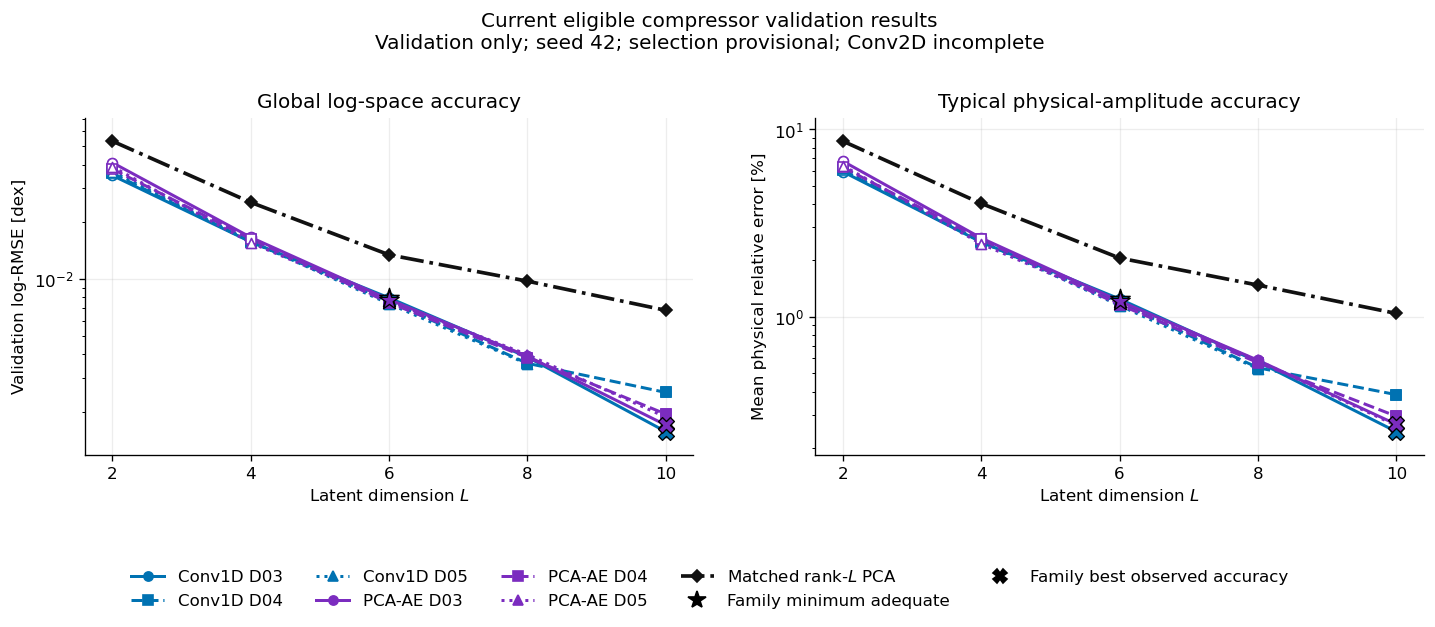

In [8]:
def pooled_metric_limits(
    metric_name: str,
    scale: float,
) -> tuple[float, float]:
    """
    Derive common logarithmic limits from all neural and PCA results.
    
    Arguments:
        metric_name (str):
            Scalar validation metric field.
        scale (float):
            Display-unit multiplier.
    
    Returns:
        limits (tuple[float, float]):
            Positive limits shared by every family notebook.
    """
    return positive_log_limits(
        scale * float(row[metric_name])
        for row in [*aggregated_results, *pca_rows]
    )


selection_handles = selection_legend_handles()
figure, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES["summary"])
for axis, metric_name in zip(
    axes,
    ("log10_rmse", "mean_relative_error"),
    strict=True,
):
    presentation = METRIC_PRESENTATION[metric_name]
    scale = float(presentation["scale"])
    plot_validation_metric_panel(
        axis,
        aggregated_results,
        pca_rows,
        LATENT_DIMENSIONS,
        metric_name,
        minimum_adequate_cell_ids=compact_cell_ids,
        best_accuracy_cell_ids=accuracy_cell_ids,
        scale=scale,
        ylabel=str(presentation["ylabel"]),
        y_limits=pooled_metric_limits(metric_name, scale),
    )
    axis.set_title(str(presentation["title"]))
handles, labels = axes[1].get_legend_handles_labels()
figure.legend(
    [*handles, *selection_handles],
    [*labels, *(handle.get_label() for handle in selection_handles)],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=5,
)
figure.suptitle(
    "Current eligible compressor validation results\n"
    "Validation only; seed 42; selection provisional; Conv2D incomplete",
    y=0.99,
)
figure.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.28,
    top=0.82,
    wspace=0.20,
)
overall_figure_path = save_figure(figure, "Overall_Validation_Performance.pdf")


## Validation-tail performance

The p95 per-surface RMS measures difficult surfaces without collapsing the result to one point. The p99 per-surface maximum measures extreme local deviations while remaining more stable than the single largest error in the full validation cube.


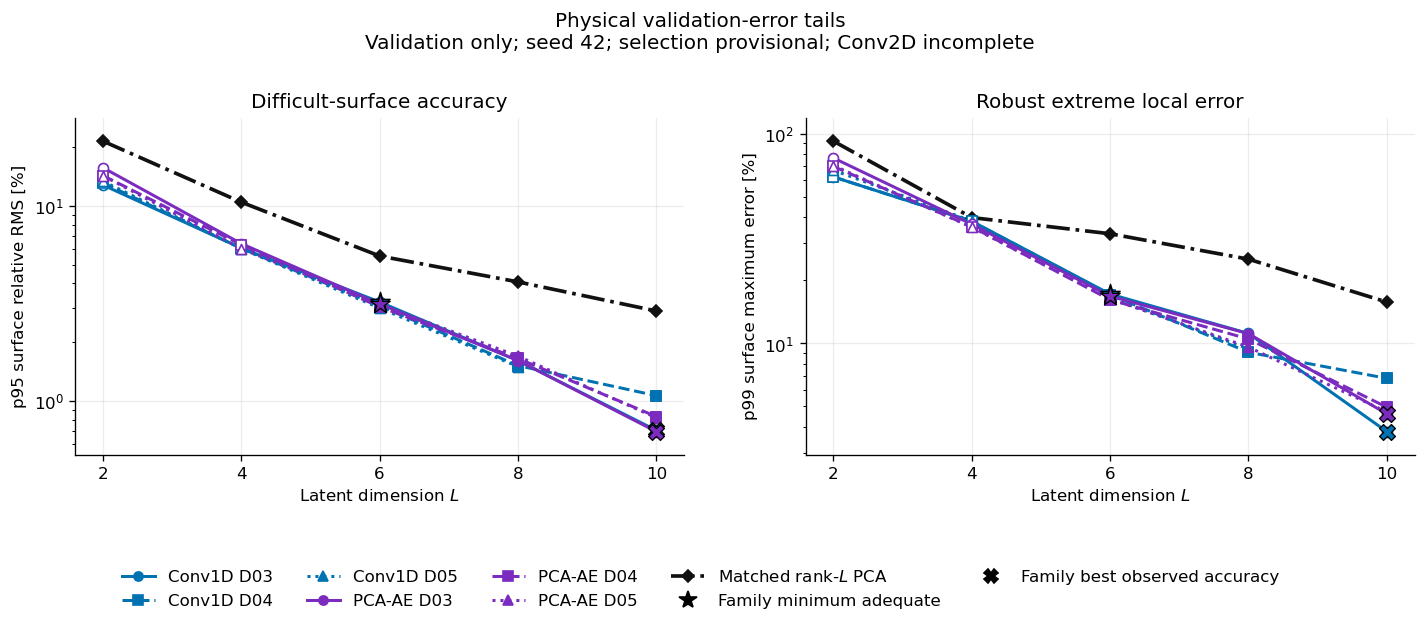

In [9]:
figure, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES["summary"])
for axis, metric_name in zip(
    axes,
    ("surface_relative_rmse_p95", "surface_relative_maximum_p99"),
    strict=True,
):
    presentation = METRIC_PRESENTATION[metric_name]
    scale = float(presentation["scale"])
    plot_validation_metric_panel(
        axis,
        aggregated_results,
        pca_rows,
        LATENT_DIMENSIONS,
        metric_name,
        minimum_adequate_cell_ids=compact_cell_ids,
        best_accuracy_cell_ids=accuracy_cell_ids,
        scale=scale,
        ylabel=str(presentation["ylabel"]),
        y_limits=pooled_metric_limits(metric_name, scale),
    )
    axis.set_title(str(presentation["title"]))
handles, labels = axes[1].get_legend_handles_labels()
figure.legend(
    [*handles, *selection_handles],
    [*labels, *(handle.get_label() for handle in selection_handles)],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=5,
)
figure.suptitle(
    "Physical validation-error tails\n"
    "Validation only; seed 42; selection provisional; Conv2D incomplete",
    y=0.99,
)
figure.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.28,
    top=0.82,
    wspace=0.20,
)
tail_figure_path = save_figure(figure, "Tail_Validation_Performance.pdf")


## Direct evidence relative to matched-rank PCA

Each heatmap cell compares a neural compressor to PCA at exactly the same latent/rank dimension. Positive percentages mean lower neural error. Grey cells are genuinely absent or incomplete and are not interpolated.


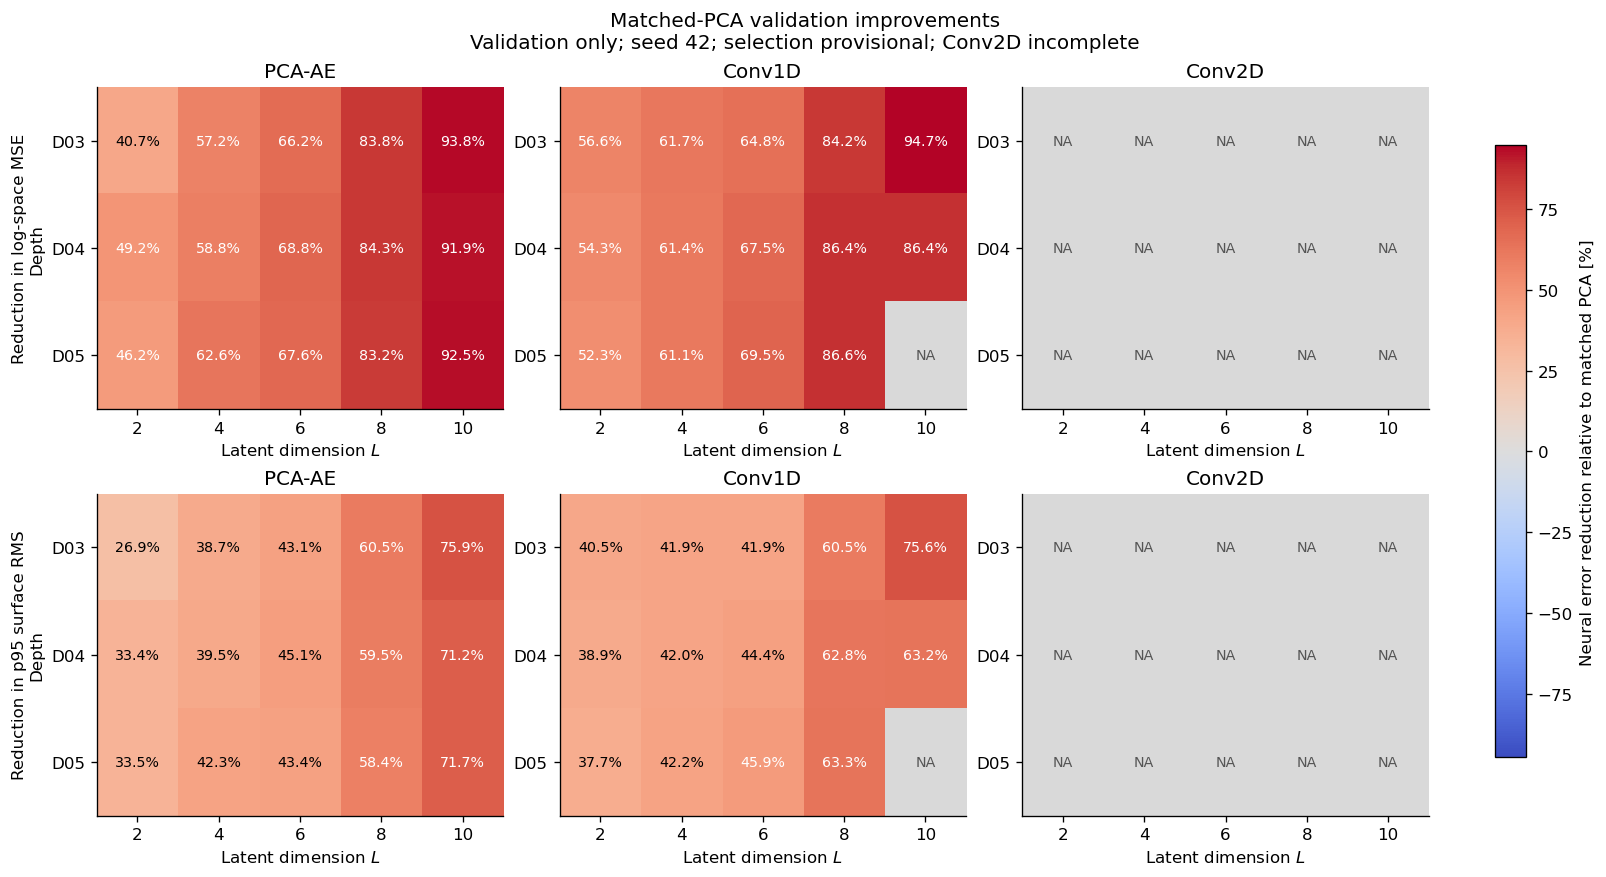

In [10]:
architecture_order = ("PCA_AE", "Conv1D", "Conv2D")
reduction_metrics = (
    ("log10_mse", "Reduction in log-space MSE"),
    ("surface_relative_rmse_p95", "Reduction in p95 surface RMS"),
)
reduction_values = []
for row in aggregated_results:
    for metric_name, _ in reduction_metrics:
        reduction_values.append(100.0 * row["fractional_error_reduction"][metric_name])
absolute_limit = max(5.0, float(np.max(np.abs(reduction_values))))
normalization = TwoSlopeNorm(
    vmin=-absolute_limit,
    vcenter=0.0,
    vmax=absolute_limit,
)
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad("#D9D9D9")

figure, axes = plt.subplots(2, 3, figsize=(13.3, 7.2), constrained_layout=True)
for row_index, (metric_name, row_title) in enumerate(reduction_metrics):
    for column_index, architecture in enumerate(architecture_order):
        axis = axes[row_index, column_index]
        matrix = np.full((len(DEPTHS), len(LATENT_DIMENSIONS)), np.nan)
        for result in aggregated_results:
            if result["architecture"] != architecture:
                continue
            depth_index = DEPTHS.index(result["depth"])
            latent_index = LATENT_DIMENSIONS.index(result["latent_dim"])
            matrix[depth_index, latent_index] = 100.0 * result[
                "fractional_error_reduction"
            ][metric_name]
        image = axis.imshow(matrix, cmap=cmap, norm=normalization, aspect="auto")
        axis.grid(False)
        axis.set_xticks(range(len(LATENT_DIMENSIONS)), LATENT_DIMENSIONS)
        axis.set_yticks(
            range(len(DEPTHS)),
            [depth.replace("Depth", "D") for depth in DEPTHS],
        )
        axis.set_xlabel("Latent dimension $L$")
        if column_index == 0:
            axis.set_ylabel(row_title + "\nDepth")
        axis.set_title(architecture.replace("_", "-"))
        for depth_index in range(len(DEPTHS)):
            for latent_index in range(len(LATENT_DIMENSIONS)):
                value = matrix[depth_index, latent_index]
                text = "NA" if not np.isfinite(value) else f"{value:.1f}%"
                color = "#555555" if not np.isfinite(value) else (
                    "white" if abs(value) > 0.48 * absolute_limit else "black"
                )
                axis.text(
                    latent_index,
                    depth_index,
                    text,
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    color=color,
                )
figure.colorbar(
    image,
    ax=axes,
    label="Neural error reduction relative to matched PCA [%]",
    shrink=0.84,
)
figure.suptitle(
    "Matched-PCA validation improvements\n"
    "Validation only; seed 42; selection provisional; Conv2D incomplete"
)
reduction_figure_path = save_figure(figure, "Matched_PCA_Error_Reduction.pdf")


## Accuracy-complexity decisions

Separate neural-only two-objective lower envelopes show what is gained by increasing the per-surface representation length and by increasing the shared model state. PCA is retained as a benchmark but is excluded from the neural candidate envelope and selection. This is more interpretable than treating a large collection of five-objective non-dominated points as one frontier. Stars mark family minimum-adequate configurations; crosses mark family accuracy champions.


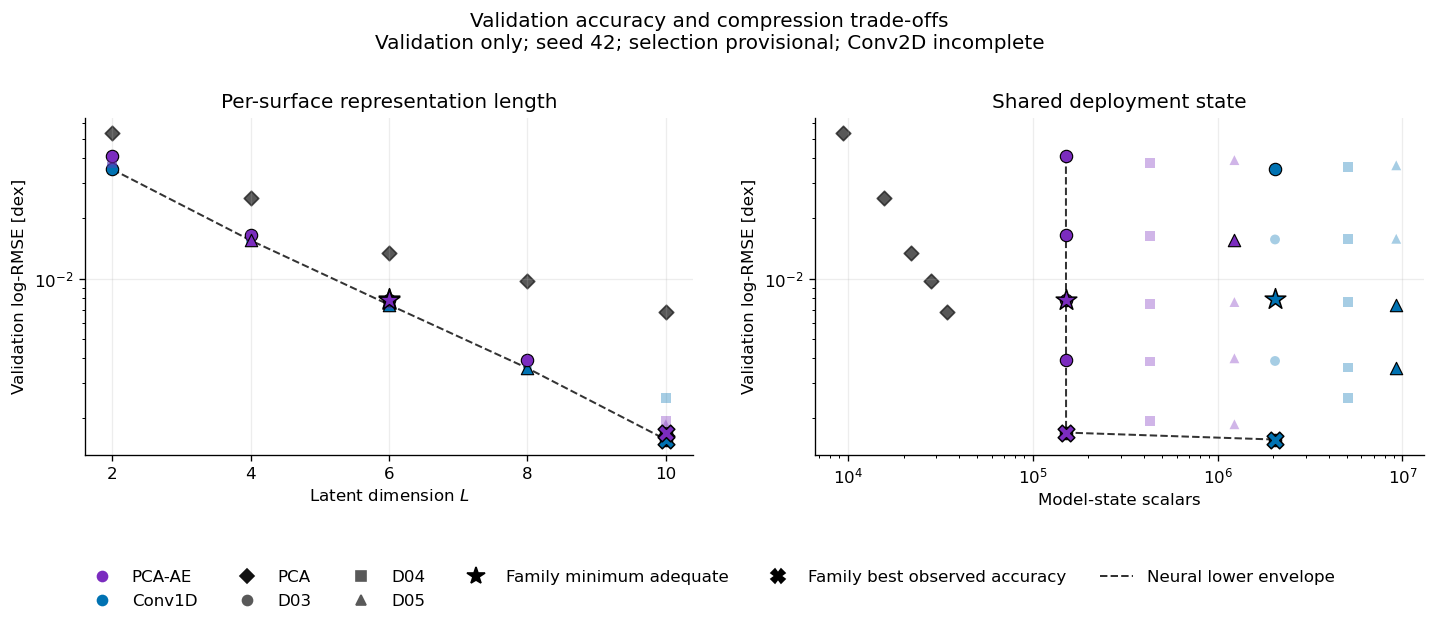

In [11]:
def lower_envelope(
    rows: list[dict],
    x_name: str,
) -> list[dict]:
    """
    Return the strict lower log-RMSE envelope along one complexity axis.
    
    Arguments:
        rows (list[dict]):
            Aggregated neural configuration records.
        x_name (str):
            Complexity field used on the horizontal axis.
    
    Returns:
        envelope (list[dict]):
            Ordered records that improve log-RMSE as complexity increases.
    """
    best_by_x = {}
    for row in rows:
        x_value = row[x_name]
        if x_value not in best_by_x or (
            row["log10_rmse"], row["cell_id"]
        ) < (
            best_by_x[x_value]["log10_rmse"],
            best_by_x[x_value]["cell_id"],
        ):
            best_by_x[x_value] = row
    envelope = []
    best_error = float("inf")
    for x_value in sorted(best_by_x):
        row = best_by_x[x_value]
        if row["log10_rmse"] < best_error:
            envelope.append(row)
            best_error = row["log10_rmse"]
    return envelope


latent_envelope = lower_envelope(aggregated_results, "latent_dim")
state_envelope = lower_envelope(aggregated_results, "codec_state_scalars")
envelope_cell_ids = {
    row["cell_id"] for row in [*latent_envelope, *state_envelope]
}

figure, axes = plt.subplots(1, 2, figsize=FIGURE_SIZES["summary"])
for row in aggregated_results:
    color = FAMILY_COLORS[row["architecture"]]
    marker = DEPTH_MARKERS[row["depth"]]
    on_envelope = row["cell_id"] in envelope_cell_ids
    for axis, x_name in zip(
        axes,
        ("latent_dim", "codec_state_scalars"),
        strict=True,
    ):
        axis.scatter(
            row[x_name],
            row["log10_rmse"],
            color=color,
            marker=marker,
            s=55 if on_envelope else 35,
            alpha=1.0 if on_envelope else 0.35,
            edgecolor="black" if on_envelope else "none",
            linewidth=0.7,
            zorder=3,
        )
for axis, x_name, envelope in (
    (axes[0], "latent_dim", latent_envelope),
    (axes[1], "codec_state_scalars", state_envelope),
):
    axis.plot(
        [row[x_name] for row in envelope],
        [row["log10_rmse"] for row in envelope],
        color="0.2",
        linestyle="--",
        linewidth=1.2,
        label="Neural two-objective lower envelope",
        zorder=2,
    )
for row in pca_rows:
    axes[0].scatter(
        row["latent_dim"],
        row["log10_rmse"],
        color=FAMILY_COLORS["PCA"],
        marker="D",
        s=38,
        alpha=0.7,
    )
    axes[1].scatter(
        row["codec_state_scalars"],
        row["log10_rmse"],
        color=FAMILY_COLORS["PCA"],
        marker="D",
        s=38,
        alpha=0.7,
    )
for row in aggregated_results:
    if row["cell_id"] not in compact_cell_ids | accuracy_cell_ids:
        continue
    marker = (
        SELECTION_MARKERS["minimum_adequate"]
        if row["cell_id"] in compact_cell_ids
        else SELECTION_MARKERS["best_observed_accuracy"]
    )
    size = 170 if marker == "*" else 100
    for axis, x_name in zip(
        axes,
        ("latent_dim", "codec_state_scalars"),
        strict=True,
    ):
        axis.scatter(
            row[x_name],
            row["log10_rmse"],
            color=FAMILY_COLORS[row["architecture"]],
            marker=marker,
            s=size,
            edgecolor="black",
            linewidth=0.9,
            zorder=6,
        )
axes[0].set_xlabel("Latent dimension $L$")
axes[0].set_xticks(LATENT_DIMENSIONS)
axes[0].set_ylabel("Validation log-RMSE [dex]")
axes[0].set_yscale("log")
axes[0].set_title("Per-surface representation length")
axes[1].set_xlabel("Model-state scalars")
axes[1].set_ylabel("Validation log-RMSE [dex]")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Shared deployment state")

legend_handles = []
legend_labels = []
available_architectures = {row["architecture"] for row in aggregated_results}
for architecture in ("PCA_AE", "Conv1D", "Conv2D"):
    if architecture not in available_architectures:
        continue
    legend_handles.append(
        Line2D(
            [],
            [],
            color=FAMILY_COLORS[architecture],
            marker="o",
            linestyle="none",
        )
    )
    legend_labels.append(architecture.replace("_", "-"))
legend_handles.append(
    Line2D(
        [],
        [],
        color=FAMILY_COLORS["PCA"],
        marker="D",
        linestyle="none",
    )
)
legend_labels.append("PCA")
for depth in DEPTHS:
    legend_handles.append(
        Line2D(
            [],
            [],
            color="0.35",
            marker=DEPTH_MARKERS[depth],
            linestyle="none",
        )
    )
    legend_labels.append(depth.replace("Depth", "D"))
legend_handles.extend(selection_handles)
legend_labels.extend(handle.get_label() for handle in selection_handles)
legend_handles.append(
    Line2D([], [], color="0.2", linestyle="--", linewidth=1.2)
)
legend_labels.append("Neural lower envelope")
figure.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=6,
)
figure.suptitle(
    "Validation accuracy and compression trade-offs\n"
    "Validation only; seed 42; selection provisional; Conv2D incomplete",
    y=0.99,
)
figure.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.28,
    top=0.82,
    wspace=0.20,
)
accuracy_complexity_figure_path = save_figure(
    figure,
    "Validation_Accuracy_Complexity.pdf",
)


In [12]:
all_core_metrics_improved = all(
    row["fractional_error_reduction"][metric_name] > 0.0
    for row in aggregated_results
    for metric_name in (
        "log10_mse",
        "mean_relative_error",
        "surface_relative_rmse_p95",
        "surface_relative_maximum_p99",
    )
)
global_maximum_degradations = []
for row in aggregated_results:
    pca_metric = next(
        pca_row["maximum_relative_error"]
        for pca_row in pca_rows
        if pca_row["latent_dim"] == row["latent_dim"]
    )
    if row["maximum_relative_error"] > pca_metric:
        global_maximum_degradations.append(row["cell_id"])

display(
    Markdown(
        "\n".join(
            (
                "### Artifact-derived interpretation",
                "",
                f"- Eligible neural configurations: **{len(aggregated_results)}**.",
                f"- Pass the declared matched-PCA objective: **{sum(row['autoencoder_outperforms_pca'] for row in aggregated_results)}/{len(aggregated_results)}**.",
                f"- Improve all four headline metrics relative to matched PCA: **{all_core_metrics_improved}**.",
                f"- First sampled latent dimension satisfying the 99.9% variance target: **{min(row['latent_dim'] for row in qualified_results)}**.",
                f"- Single-global-maximum degradations despite robust-tail improvement: **{len(global_maximum_degradations)}**.",
                f"- Current eligible Conv2D configurations: **{sum(row['architecture'] == 'Conv2D' for row in aggregated_results)}**.",
                "- Every currently eligible configuration has one seed, so rankings have no seed-to-seed uncertainty estimate.",
                "- All decisions remain provisional until the comparison scope and replicate policy are accepted.",
            )
        )
    )
)
if global_maximum_degradations:
    display(
        Markdown(
            "Global-maximum exceptions: "
            + ", ".join(global_maximum_degradations)
        )
    )


### Artifact-derived interpretation

- Eligible neural configurations: **29**.
- Pass the declared matched-PCA objective: **29/29**.
- Improve all four headline metrics relative to matched PCA: **True**.
- First sampled latent dimension satisfying the 99.9% variance target: **6**.
- Single-global-maximum degradations despite robust-tail improvement: **4**.
- Current eligible Conv2D configurations: **0**.
- Every currently eligible configuration has one seed, so rankings have no seed-to-seed uncertainty estimate.
- All decisions remain provisional until the comparison scope and replicate policy are accepted.

Global-maximum exceptions: Direct_AE:Conv1D:Depth05:L02, PCA_AE:PCA_AE:Depth04:L04, PCA_AE:PCA_AE:Depth05:L02, PCA_AE:PCA_AE:Depth05:L04

## Reproducible live selection hand-off

The two complete CSV tables are written first. Their hashes, the exact selection policy, coverage, PCA provenance, family/global decisions, and selected diagnostic artifacts are then recorded in a compact live JSON written last. This live hand-off is always provisional and never opens the final-test gate.


In [13]:
result_csv_path = RESULT_DIRECTORY / "ValidationResults.csv"
csv_fieldnames = (
    "cell_id",
    "model_family",
    "architecture",
    "depth",
    "latent_dim",
    "n_runs",
    "n_seeds",
    "seeds",
    "representative_run_directory",
    "representative_seed",
    "representative_checkpoint_epoch",
    "learned_parameters",
    "codec_state_scalars",
    "variance_recovered",
    "log10_mse",
    "log10_rmse",
    "mean_relative_error",
    "surface_relative_rmse_p95",
    "surface_relative_maximum_p99",
    "maximum_relative_error",
    "autoencoder_outperforms_pca",
    "target_met",
    "diagnostics_ready",
    "latents_available",
    "run_directories",
)
temporary_csv_path = result_csv_path.with_name(f".{result_csv_path.name}.tmp")
with temporary_csv_path.open("w", encoding="utf-8", newline="") as stream:
    writer = csv.DictWriter(stream, fieldnames=csv_fieldnames)
    writer.writeheader()
    for row in aggregated_results:
        writer.writerow(
            {
                name: json.dumps(row[name])
                if name in {"seeds", "run_directories"}
                else row[name]
                for name in csv_fieldnames
            }
        )
temporary_csv_path.replace(result_csv_path)

audit_csv_path = RESULT_DIRECTORY / "ValidationRunAudit.csv"
audit_fieldnames = (
    "cell_id",
    "model_family",
    "architecture",
    "depth",
    "latent_dim",
    "run_directory",
    "status",
    "current_configuration",
    "configuration_sources_match",
    "training_complete",
    "validation_ready",
    "diagnostics_ready",
    "latents_available",
    "eligible_for_comparison",
    "exclusion_reasons",
    "warnings",
)
temporary_audit_path = audit_csv_path.with_name(f".{audit_csv_path.name}.tmp")
with temporary_audit_path.open("w", encoding="utf-8", newline="") as stream:
    writer = csv.DictWriter(stream, fieldnames=audit_fieldnames)
    writer.writeheader()
    for audit in run_audits:
        writer.writerow(
            {
                name: json.dumps(audit[name])
                if name in {"exclusion_reasons", "warnings"}
                else audit[name]
                for name in audit_fieldnames
            }
        )
temporary_audit_path.replace(audit_csv_path)

selection_input_after_tables = compressor_selection_input_sha256(
    PROJECT_ROOT,
    policy=SELECTION_POLICY,
    pca_metrics_path=PCA_METRICS_PATH,
    pca_metadata_path=PCA_METADATA_PATH,
    latent_dimensions=LATENT_DIMENSIONS,
)
if selection_input_after_tables != selection_input_sha256:
    raise RuntimeError(
        "Compressor inputs changed during selection; rerun ModelSelection.ipynb."
    )
if notebook_source_sha256(
    SELECTION_NOTEBOOK_PATH
) != selection_notebook_source_sha256:
    raise RuntimeError(
        "ModelSelection notebook sources changed during execution; rerun it."
    )

result_by_cell_id = {row["cell_id"]: row for row in aggregated_results}
family_selection_ids = {
    family: {
        "minimum_adequate": decision["minimum_adequate"]["cell_id"],
        "best_observed_accuracy": decision["best_observed_accuracy"]["cell_id"],
        "diagnostic_representative": decision["minimum_adequate"]["cell_id"],
    }
    for family, decision in family_decisions.items()
}
diagnostic_runs = {}
diagnostic_artifact_names = (
    "ResolvedConfig.json",
    "Architecture.json",
    "DataMetadata.json",
    "Summary.json",
    "History.json",
    "Best.pt",
    "ValidationMetrics.json",
    "ValidationDiagnostics.json",
    "ValidationDiagnostics.npz",
    "Latents.hdf5",
)
for family, selection in family_selection_ids.items():
    row = result_by_cell_id[selection["diagnostic_representative"]]
    run_directory = PROJECT_ROOT / row["representative_run_directory"]
    missing_artifacts = [
        name
        for name in diagnostic_artifact_names
        if not (run_directory / name).is_file()
    ]
    if missing_artifacts:
        raise RuntimeError(
            f"Selected {family} diagnostics are incomplete: {missing_artifacts}."
        )
    diagnostic_runs[family] = {
        "cell_id": row["cell_id"],
        "model_family": row["model_family"],
        "architecture": row["architecture"],
        "depth": row["depth"],
        "latent_dim": row["latent_dim"],
        "run_directory": row["representative_run_directory"],
        "seed": row["representative_seed"],
        "checkpoint_epoch": row["representative_checkpoint_epoch"],
        "artifact_sha256": {
            name: file_sha256(run_directory / name)
            for name in diagnostic_artifact_names
        },
    }

expected_cell_ids = {cell["cell_id"] for cell in expected_cells}
eligible_cell_ids = {row["cell_id"] for row in aggregated_results}
live_selection = {
    "kind": "validation_selection_live",
    "status": "provisional_validation",
    "created_at_utc": AUDIT_CREATED_AT,
    "git": git_state(),
    "selection_scope": ["PCA_AE", "Conv1D", "Conv2D"],
    "policy": SELECTION_POLICY,
    "coverage": {
        "scope_complete": eligible_cell_ids == expected_cell_ids,
        "expected_cells": len(expected_cell_ids),
        "eligible_cells": len(eligible_cell_ids),
        "audit_record_status_counts": dict(sorted(status_counts.items())),
        "by_architecture": coverage_by_architecture,
        "unavailable_cell_ids": sorted(expected_cell_ids - eligible_cell_ids),
    },
    "inputs": {
        "selection_input_sha256": selection_input_sha256,
        "selection_notebook": {
            "path": str(SELECTION_NOTEBOOK_PATH.relative_to(PROJECT_ROOT)),
            "source_sha256": selection_notebook_source_sha256,
        },
        "pca_metrics": {
            "path": str(PCA_METRICS_PATH.relative_to(PROJECT_ROOT)),
            "sha256": file_sha256(PCA_METRICS_PATH),
        },
        "pca_metadata": {
            "path": str(PCA_METADATA_PATH.relative_to(PROJECT_ROOT)),
            "sha256": file_sha256(PCA_METADATA_PATH),
        },
    },
    "tables": {
        "results": {
            "path": str(result_csv_path.relative_to(PROJECT_ROOT)),
            "sha256": file_sha256(result_csv_path),
        },
        "audit": {
            "path": str(audit_csv_path.relative_to(PROJECT_ROOT)),
            "sha256": file_sha256(audit_csv_path),
        },
    },
    "selections": {
        "by_family": family_selection_ids,
        "global": {
            "minimum_adequate": global_minimum_adequate["cell_id"],
            "best_observed_accuracy": global_best_accuracy["cell_id"],
        },
        "matched_pca_all_core_metrics_improved": all_core_metrics_improved,
        "global_maximum_degradation_cell_ids": global_maximum_degradations,
        "neural_latent_lower_envelope_cell_ids": [
            row["cell_id"] for row in latent_envelope
        ],
        "neural_state_lower_envelope_cell_ids": [
            row["cell_id"] for row in state_envelope
        ],
    },
    "diagnostic_runs": diagnostic_runs,
    "test_gate": {
        "selection_frozen": False,
        "frozen_run_directory": None,
        "test_evaluation_allowed": False,
    },
}

live_selection_path = RESULT_DIRECTORY / "ValidationSelectionLive.json"
save_json(live_selection, live_selection_path)

print(f"Live selection: {live_selection_path.relative_to(PROJECT_ROOT)}")
print(f"Result table: {result_csv_path.relative_to(PROJECT_ROOT)}")
print(f"Run audit: {audit_csv_path.relative_to(PROJECT_ROOT)}")
print("Final-test gate: CLOSED")


Live selection: Data/NLA/Comparison/ValidationSelectionLive.json
Result table: Data/NLA/Comparison/ValidationResults.csv
Run audit: Data/NLA/Comparison/ValidationRunAudit.csv
Final-test gate: CLOSED


## Final consistency checks

These assertions verify deterministic decisions, table and artifact authentication, live-input freshness, closed test access, and figure production. Scientific outcomes themselves are reported rather than hard-coded, so future completed configurations can change the conclusions transparently.


In [14]:
assert len({row["cell_id"] for row in aggregated_results}) == len(
    aggregated_results
)
assert all(row["n_seeds"] >= 1 for row in aggregated_results)
assert global_minimum_adequate == minimum_adequate_result(aggregated_results)
assert global_best_accuracy == best_accuracy_result(aggregated_results)
assert all(
    decision["minimum_adequate"] == minimum_adequate_result(family_rows[family])
    for family, decision in family_decisions.items()
)
assert all(
    decision["best_observed_accuracy"] == best_accuracy_result(
        family_rows[family]
    )
    for family, decision in family_decisions.items()
)
assert live_selection["kind"] == "validation_selection_live"
assert live_selection["status"] == "provisional_validation"
assert live_selection["test_gate"]["selection_frozen"] is False
assert live_selection["test_gate"]["test_evaluation_allowed"] is False
assert file_sha256(result_csv_path) == live_selection["tables"]["results"]["sha256"]
assert file_sha256(audit_csv_path) == live_selection["tables"]["audit"]["sha256"]
assert compressor_selection_input_sha256(
    PROJECT_ROOT,
    policy=live_selection["policy"],
    pca_metrics_path=PROJECT_ROOT / live_selection["inputs"]["pca_metrics"]["path"],
    pca_metadata_path=PROJECT_ROOT / live_selection["inputs"]["pca_metadata"]["path"],
    latent_dimensions=tuple(live_selection["policy"]["latent_dimensions"]),
) == live_selection["inputs"]["selection_input_sha256"]
assert notebook_source_sha256(
    PROJECT_ROOT / live_selection["inputs"]["selection_notebook"]["path"]
) == live_selection["inputs"]["selection_notebook"]["source_sha256"]
for diagnostic in diagnostic_runs.values():
    run_directory = PROJECT_ROOT / diagnostic["run_directory"]
    assert all(
        file_sha256(run_directory / name) == digest
        for name, digest in diagnostic["artifact_sha256"].items()
    )
expected_figure_paths = (
    overall_figure_path,
    tail_figure_path,
    reduction_figure_path,
    accuracy_complexity_figure_path,
)
assert all(path.is_file() and path.stat().st_size > 0 for path in expected_figure_paths)
assert not (FIGURE_DIRECTORY / "Validation_Pareto_Frontiers.pdf").samefile(
    accuracy_complexity_figure_path
) if (FIGURE_DIRECTORY / "Validation_Pareto_Frontiers.pdf").exists() else True

print("Validated live selection and outputs:")
for path in expected_figure_paths:
    print(path.relative_to(PROJECT_ROOT))


Validated live selection and outputs:
Figure/NLA/ModelSelection/Overall_Validation_Performance.pdf
Figure/NLA/ModelSelection/Tail_Validation_Performance.pdf
Figure/NLA/ModelSelection/Matched_PCA_Error_Reduction.pdf
Figure/NLA/ModelSelection/Validation_Accuracy_Complexity.pdf
